# IMDB Movie-Review Sentiment - Naive Bayes implemented from scratch

**HIT - Machine Learning course assignment**

| Student | ID (last 4 digits) |
|---|---|
| Tomer R. | 5130 |

- **Assignment type:** text analysis (NLP)
- **Learning type:** binary classification (positive vs negative review sentiment)
- **Algorithm implemented from scratch:** Naive Bayes - Multinomial, with a Bernoulli variant
- **Quality metric:** F1 macro-average
- **Dataset:** [IMDB 50K Movie Reviews](https://www.kaggle.com/datasets/atulanandjha/imdb-50k-movie-reviews-test-your-bert)
  (Stanford *Large Movie Review Dataset*), shipped pre-split into 25,000 train / 25,000 test, balanced 50/50.

This notebook runs a full supervised-learning flow: load the fixed train/test split, engineer text
features, implement Naive Bayes from scratch, tune it with 5-fold cross-validated grid search on the
training set only, retrain the best configuration on the whole training set, and evaluate once on the
untouched test set.

---
## Part 1 - Introduction

### 1a. AI assistance - prompts, tools and resources used

This assignment was developed with the help of **Claude (Anthropic)**, used through *Claude Code*.
All generated code and explanations were read, checked and understood before inclusion; the Naive
Bayes derivation below is standard textbook material (Manning, Raghavan & Schuetze, *Introduction to
Information Retrieval*, ch. 13) and was cross-checked against the scikit-learn user guide.

**What the AI was used for, with representative prompts (paraphrased):**

| Purpose | Prompt (paraphrased) |
|---|---|
| Understand the (machine-translated) brief | *"Read the assignment brief and explain exactly what each part requires."* |
| Choose a suitable dataset | *"Is the IMDB 50K movie-review dataset a good fit for a from-scratch Naive Bayes text-classification task that needs a pre-split train/test set with labels on both?"* |
| Derive and implement the algorithm | *"Derive Multinomial and Bernoulli Naive Bayes and implement them from scratch with a scikit-learn-style fit/predict, Laplace/Lidstone alpha smoothing and a fit_prior option, working in log space."* |
| Design the evaluation | *"Design a leakage-safe 5-fold cross-validated grid search over feature-engineering options x Naive Bayes hyper-parameters; the vectorizer must be fit inside each fold."* |
| Explanatory writing | *"Explain TF-IDF / n-grams / Laplace smoothing for a viewer who does not know the material."* |

**Other resources:**

- scikit-learn User Guide - *Naive Bayes* and *Working with text data*.
- NLTK documentation - stopword list and the Porter stemmer.
- Stanford *Large Movie Review Dataset* page (Maas et al., 2011).

### 1b. The learning problem and the dataset

We tackle **binary sentiment classification**: given the free text of an IMDB movie review, predict
whether the reviewer's opinion is **positive** or **negative**. The data is the Stanford *Large Movie
Review Dataset* (accessed via Kaggle): 50,000 "highly polar" English reviews - reviews rated 5 or 6
out of 10 were deliberately excluded, so every example is clearly positive (rating >= 7) or clearly
negative (rating <= 4). It arrives **already split** into 25,000 training and 25,000 test reviews,
each split perfectly balanced (12,500 positive + 12,500 negative), with a disjoint set of movies in
each. We keep this split fixed: the test set is set aside and used exactly once, at the very end.
All model selection happens by 5-fold cross-validation inside the training set.

### 1c. Setup

In [1]:
import re
import time
import random
import warnings
from pathlib import Path
from itertools import product

# Corporate networks often run a TLS-intercepting proxy that Python's bundled CA list
# does not trust. truststore makes Python use the OS trust store instead. On Colab / a
# normal network this is a harmless no-op.
try:
    import truststore
    truststore.inject_into_ssl()
except Exception:
    pass

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB as SklearnMultinomialNB  # reference parity check only

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")  # tqdm in a plain kernel

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.5.2 | pandas 3.0.5


### 1d. Load the train and test sets

The Kaggle dataset ships the **official Stanford split** as two files, `train.csv` and `test.csv`
(25,000 rows each), with columns `text` and `sentiment` (`pos` / `neg`). We load them as-is - **we
never build or re-shuffle the split** - rename to `review` / `label`, and map `neg -> 0`,
`pos -> 1`. The only cleaning here is dropping exact duplicate reviews *within* the training set
(96 of them); the test set is left completely untouched.

In [2]:
def load_imdb():
    # Return (df_train, df_test), each with columns ['review', 'label'] (label 0 = neg, 1 = pos).
    # Downloads from Kaggle via kagglehub (anonymous access works for this public dataset),
    # with a data/ folder fallback. The dataset's own train.csv / test.csv are the fixed split.
    root = None
    try:
        import kagglehub
        root = Path(kagglehub.dataset_download("atulanandjha/imdb-50k-movie-reviews-test-your-bert"))
    except Exception as e:
        print("kagglehub download failed (%r); looking in data/" % (e,))

    def _find(name):
        for base in [p for p in (root, Path("data")) if p is not None]:
            hits = sorted(base.rglob(name))
            if hits:
                return hits[0]
        return None

    def _read(path):
        try:
            df = pd.read_csv(path)
        except UnicodeDecodeError:
            df = pd.read_csv(path, encoding="latin-1")
        df.columns = [c.strip().lower() for c in df.columns]
        df = df.rename(columns={"sentimenttext": "review", "text": "review",
                                "sentiment": "label", "review_text": "review"})
        df = df[["review", "label"]].dropna()
        df["review"] = df["review"].astype(str)
        df["label"] = df["label"].map({"pos": 1, "neg": 0, "positive": 1, "negative": 0,
                                       1: 1, 0: 0, "1": 1, "0": 0})
        return df.dropna(subset=["label"]).astype({"label": int}).reset_index(drop=True)

    tr_path, te_path = _find("train.csv"), _find("test.csv")
    if tr_path is None or te_path is None:
        raise FileNotFoundError("train.csv / test.csv not found via kagglehub or data/")
    print("train file:", tr_path)
    print("test  file:", te_path)

    tr = _read(tr_path).drop_duplicates(subset="review").reset_index(drop=True)
    te = _read(te_path)
    return tr, te


df_train, df_test = load_imdb()
print("train:", df_train.shape, "  test:", df_test.shape)

train file: /Users/traz/.cache/kagglehub/datasets/atulanandjha/imdb-50k-movie-reviews-test-your-bert/versions/2/train.csv
test  file: /Users/traz/.cache/kagglehub/datasets/atulanandjha/imdb-50k-movie-reviews-test-your-bert/versions/2/test.csv


train: (24904, 2)   test: (25000, 2)


**First 5 rows of the training set:**

In [3]:
df_train.head()

,review,label
0,"Now, I won't deny that when I purchased this off eBay, I had high expectations. This was an incredible out-of-print work from the master of comedy that I so enjoy. However, I was soon to be disapp...",0
1,"The saddest thing about this ""tribute"" is that almost all the singers (including the otherwise incredibly talented Nick Cave) seem to have missed the whole point where Cohen's intensity lies: by d...",0
2,"Last night I decided to watch the prequel or shall I say the so called prequel to Carlito's Way - ""Carlito's Way: Rise to Power (2005)"" which went straight to DVD...no wonder .....it completely .....",0
3,"I have to admit that i liked the first half of Sleepers. It looked good, the acting was even better, the story of childhood, pain and revenge was interesting and moving. A superior hollywood film....",0
4,"I was not impressed about this film especially for the fact that I went to the cinema with my family in good faith to see a film which was certificate rated 12A here in the UK. To my dismay, this ...",0


**First 5 rows of the test set:**

In [4]:
df_test.head()

,review,label
0,"My daughter liked it but I was aghast, that a character in this movie smokes. As if it isn't awful enough to see ""product placement"" actors like Bruce Willis who smoke in their movies - at least c...",0
1,I... No words. No words can describe this. I will try for the sake of those few brave people who stick knives into their toasters... after watching this show.<br /><br />This... Cosgrove person......,0
2,"this film is basically a poor take on the old urban legend of the babysitter who gets crank calls telling her to check the children, she calls the police who trace the calls and find there coming ...",0
3,"This is a terrible movie, and I'm not even sure why it's so terrible. It's ugly, for one, with that trendy 1970s visual style that maybe seemed like a good idea at the time but which now enables o...",0
4,"First of all this movie is a piece of reality very well realized artistically. Some kind of combination between ""American Beauty"" and ""As Good as it gets"". And of course something specifically to ...",1


### 1e. A quick look at the data

Both splits should be balanced 50/50. We also check for obvious data-quality issues and glance at
review length, which motivates a few feature-engineering choices in Part 2 (HTML `<br />` tags to
strip, very long reviews, and so on).

train n= 24904  neg(0)= 12432  pos(1)= 12472  nulls=0  empty=0
test  n= 25000  neg(0)= 12500  pos(1)= 12500  nulls=0  empty=0

exact review text shared between train and test: 123 (0.49% of test) - left as-is; too small to matter and we must not alter the given split


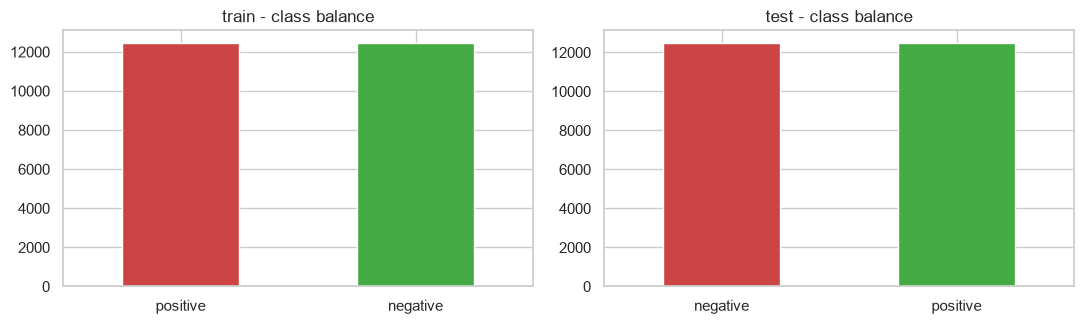


review length (words): min 10, median 174, mean 234, 95th pct 599, max 2470

example raw review (first 400 chars):
 Now, I won't deny that when I purchased this off eBay, I had high expectations. This was an incredible out-of-print work from the master of comedy that I so enjoy. However, I was soon to be disappointed. Apologies to those who enjoyed it, but I just found the Compleat Al to be very difficult to watch. I got a few smiles, sure, but the majority of the funny came from the music videos (which I've go


In [5]:
for name, d in [("train", df_train), ("test", df_test)]:
    c = d["label"].value_counts().sort_index()
    print("%-5s n=%6d  neg(0)=%6d  pos(1)=%6d  nulls=%d  empty=%d" % (
        name, len(d), c.get(0, 0), c.get(1, 0),
        d["review"].isna().sum(), (d["review"].str.strip() == "").sum()))

overlap = len(set(df_train["review"]) & set(df_test["review"]))
print("\nexact review text shared between train and test: %d (%.2f%% of test) - left as-is; "
      "too small to matter and we must not alter the given split" % (overlap, 100 * overlap / len(df_test)))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, (name, d) in zip(ax, [("train", df_train), ("test", df_test)]):
    (d["label"].map({0: "negative", 1: "positive"}).value_counts()
        .plot.bar(ax=a, color=["#cc4444", "#44aa44"]))
    a.set_title(name + " - class balance"); a.set_xlabel(""); a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

wl = df_train["review"].str.split().str.len()
print("\nreview length (words): min %d, median %d, mean %.0f, 95th pct %d, max %d" % (
    wl.min(), wl.median(), wl.mean(), wl.quantile(0.95), wl.max()))
print("\nexample raw review (first 400 chars):\n", df_train["review"].iloc[0][:400])

---
## Quality index - which metric, and why

The brief fixes the metric by problem type:

| Problem type | Metric |
|---|---|
| Regression | R-squared |
| Multi-class, **or** binary with no single "class of interest" | **F1, macro-averaged** |
| Binary with one "central" class of interest (e.g. *spam* in spam detection) | F1 of that class only |

Our problem is **binary** (positive / negative) and the classes are **balanced and equally
important** - there is no single "central" class we care about more, unlike spam detection. So the
middle row applies: **macro-averaged F1** - F1 for the positive class and F1 for the negative class,
averaged. On perfectly balanced data this sits very close to plain accuracy and to positive-class
F1, but it is the metric the brief asks for and it stays honest if a preprocessing choice ever
unbalances a validation fold.

`score()` below is the single scoring function used **everywhere**: every fold in cross-validation,
the grid-search ranking, and the final test-set report.

In [6]:
def score(y_true, y_pred):
    # Macro-averaged F1 - the assignment's quality index for this problem.
    return f1_score(y_true, y_pred, average="macro")


print("score() smoke test:", round(score([0, 0, 1, 1, 1], [0, 1, 1, 1, 0]), 4))

score() smoke test: 0.5833


---
## Part 2 - Feature engineering

A learning algorithm needs numbers, not prose. Feature engineering is the process of turning each
raw review into a fixed-length numeric vector. For text the standard pipeline is:

**1. Text cleaning / normalisation.** Lower-case everything (so *Great* and *great* are the same
token), strip the HTML that litters these reviews (`<br />`), drop URLs, and remove digits and
punctuation. This shrinks the vocabulary to the parts that carry meaning.

**2. Tokenisation.** Split the cleaned string into *tokens* (here: runs of >= 2 letters). A review
becomes a list of words.

**3. Optional token filtering.**
- *Stop-word removal* - drop extremely common words (`the`, `is`, `and`, ...). It trims noise, but
  note that English stop-word lists also contain `not`, `no`, `very`, `never` - words that clearly
  matter for **sentiment** - so for this task removing them can *hurt*. We therefore make it a knob
  and test both settings in Part 6a.
- *Stemming* - chop words to a common root (`amazing`, `amazed`, `amazingly` -> `amaz`) with the
  Porter stemmer. Fewer, denser features; occasionally over-merges.

**4. Vectorisation - from tokens to a document-term matrix.**
- *Bag-of-Words (BoW)* - one column per vocabulary term; the entry is the **count** of that term in
  the document. Order is thrown away.
- *TF-IDF* - the same matrix, but each count is reweighted by *term frequency x inverse document
  frequency*: terms that appear in almost every review (weak signal) are down-weighted, rare
  informative terms are boosted.
- *n-grams* - also index short word sequences. Unigrams `(1,1)` treat `not good` as `not` + `good`;
  adding bigrams `(1,2)` gives the model the single feature `not good`, which is very useful for
  sentiment.
- *Vocabulary pruning* - `min_df` drops terms seen in fewer than *k* documents (kills typos),
  `max_df` drops terms seen in more than a fraction of documents (kills corpus-specific stop
  words), `max_features` caps the vocabulary at the most frequent *N* terms.

The matrix is huge but almost all zeros, so it is stored **sparse**.

### 2a. Cleaning, tokenisation and the vectorizer factory

`clean_text` and `tokenize` are the actual functions the vectorizer uses (as its `preprocessor`
and `tokenizer`), so the step-by-step demo below and the full pipeline share exactly one code
path. `build_vectorizer(...)` is the single knob-box that Part 6a's grid search will sweep.

In [7]:
from functools import lru_cache
from nltk.stem import PorterStemmer

_HTML_RE = re.compile(r"<[^>]+>")
_URL_RE = re.compile(r"https?://\S+|www\.\S+")
_KEEP_RE = re.compile(r"[^a-z\s]+")       # after lower-casing, keep only letters and spaces
_TOKEN_RE = re.compile(r"[a-z]{2,}")       # tokens = runs of >= 2 letters
_stem = lru_cache(maxsize=300_000)(PorterStemmer().stem)


def clean_text(s):
    # raw review -> normalised string (lower-case, no HTML / URLs / digits / punctuation)
    s = s.lower()
    s = _HTML_RE.sub(" ", s)
    s = _URL_RE.sub(" ", s)
    s = _KEEP_RE.sub(" ", s)
    return s


def tokenize(s, use_stemming=False, remove_stopwords=False):
    # normalised string -> list of tokens, with optional stop-word removal then stemming
    toks = _TOKEN_RE.findall(s)
    if remove_stopwords:
        toks = [t for t in toks if t not in ENGLISH_STOP_WORDS]
    if use_stemming:
        toks = [_stem(t) for t in toks]
    return toks


def build_vectorizer(kind="tfidf", ngram_range=(1, 1), use_stemming=False,
                     remove_stopwords=False, min_df=5, max_df=0.9,
                     max_features=50_000, binary=False):
    # Return a configured (unfitted) CountVectorizer / TfidfVectorizer.
    # kind: "bow" (counts) or "tfidf". binary=True + "bow" pairs with Bernoulli NB.
    shared = dict(
        preprocessor=clean_text,
        tokenizer=lambda s: tokenize(s, use_stemming, remove_stopwords),
        token_pattern=None,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
    )
    if kind == "bow":
        return CountVectorizer(binary=binary, **shared)
    if kind == "tfidf":
        return TfidfVectorizer(**shared)
    raise ValueError("kind must be 'bow' or 'tfidf'")


print("stemmer check:", [_stem(w) for w in ["amazing", "amazed", "amazingly", "movies", "acting"]])
print("clean_text on a snippet:", repr(clean_text("It's <br />GREAT!! visit http://x.com 10/10")))

stemmer check: ['amaz', 'amaz', 'amazingli', 'movi', 'act']
clean_text on a snippet: 'it s  great  visit    '


### 2b. The pipeline step-by-step on real examples

Three reviews - a positive and a negative one from **train**, and one from **test** - taken through
every text stage:

In [8]:
demo = pd.concat([
    df_train[df_train.label == 1].iloc[[0]].assign(split="train"),
    df_train[df_train.label == 0].iloc[[0]].assign(split="train"),
    df_test.iloc[[1]].assign(split="test"),
], ignore_index=True)

stages = []
for _, r in demo.iterrows():
    cleaned = clean_text(r["review"])
    toks = tokenize(cleaned)
    no_stop = tokenize(cleaned, remove_stopwords=True)
    stemmed = tokenize(cleaned, use_stemming=True, remove_stopwords=True)
    stages.append({
        "split": r["split"],
        "label": int(r["label"]),
        "1_raw (first 140 chars)": r["review"][:140] + " ...",
        "2_cleaned (first 140)": cleaned[:140] + " ...",
        "3_tokens (n)": len(toks),
        "4_tokens (first 16)": " ".join(toks[:16]),
        "5_minus_stopwords (first 16)": " ".join(no_stop[:16]),
        "6_stemmed (first 16)": " ".join(stemmed[:16]),
    })
pd.set_option("display.max_colwidth", 160)
pd.DataFrame(stages).T

,0,1,2
split,train,train,test
label,1,0,0
1_raw (first 140 chars),"The original movie, The Odd Couple, has some wonderful comic one-liners. The entire world it seems knows the story of neurotic neat-freak Fe ...","Now, I won't deny that when I purchased this off eBay, I had high expectations. This was an incredible out-of-print work from the master of ...",I... No words. No words can describe this. I will try for the sake of those few brave people who stick knives into their toasters... after w ...
2_cleaned (first 140),the original movie the odd couple has some wonderful comic one liners the entire world it seems knows the story of neurotic neat freak fe ...,now i won t deny that when i purchased this off ebay i had high expectations this was an incredible out of print work from the master of ...,i no words no words can describe this i will try for the sake of those few brave people who stick knives into their toasters after watch ...
3_tokens (n),502,132,303
4_tokens (first 16),the original movie the odd couple has some wonderful comic one liners the entire world it,now won deny that when purchased this off ebay had high expectations this was an incredible,no words no words can describe this will try for the sake of those few brave
5_minus_stopwords (first 16),original movie odd couple wonderful comic liners entire world knows story neurotic neat freak felix ungar,won deny purchased ebay high expectations incredible print work master comedy enjoy soon disappointed apologies enjoyed,words words try sake brave people stick knives toasters watching cosgrove person acting like watching female
6_stemmed (first 16),origin movi odd coupl wonder comic liner entir world know stori neurot neat freak felix ungar,won deni purchas ebay high expect incred print work master comedi enjoy soon disappoint apolog enjoy,word word tri sake brave peopl stick knive toaster watch cosgrov person act like watch femal


In [9]:
# From tokens to numbers. (a) raw Bag-of-Words counts on just these 3 reviews -- the mechanism,
# but the largest counts are inevitably function words:
bow_demo = build_vectorizer(kind="bow", ngram_range=(1, 1), min_df=1, max_df=1.0, max_features=None)
Bd = bow_demo.fit_transform(demo["review"])
vd = np.array(bow_demo.get_feature_names_out())
for i in range(len(demo)):
    row = Bd[i].toarray().ravel(); nz = row.nonzero()[0]
    order = nz[np.argsort(-row[nz])][:10]
    print("doc %d (%s,label=%d): %d unique tokens; highest counts: %s"
          % (i, demo["split"][i], demo["label"][i], len(nz),
             ", ".join("%s=%d" % (vd[j], row[j]) for j in order)))

doc 0 (train,label=1): 252 unique tokens; highest counts: the=51, of=17, felix=12, that=10, is=10, and=8, in=8, movie=8, very=7, it=7
doc 1 (train,label=0): 91 unique tokens; highest counts: the=8, to=7, that=4, this=4, was=4, al=3, of=3, just=3, off=2, it=2
doc 2 (test,label=0): 188 unique tokens; highest counts: the=23, of=19, this=10, you=6, that=6, show=5, have=5, for=4, her=4, if=4


In [10]:
# (b) the same 3 reviews as TF-IDF over unigrams+bigrams, with the IDF weights and vocabulary
# learned from the FULL training set (min_df=5) -- now the sentiment-bearing terms rise to the top.
base_vec = build_vectorizer(kind="tfidf", ngram_range=(1, 2), min_df=5, max_features=50_000)
base_vec.fit(df_train["review"])
Td = base_vec.transform(demo["review"])
vt = base_vec.get_feature_names_out()
for i in range(len(demo)):
    row = Td[i].toarray().ravel(); nz = row.nonzero()[0]
    order = nz[np.argsort(-row[nz])][:12]
    print("doc %d (%s,label=%d): %d non-zero features; highest TF-IDF: %s"
          % (i, demo["split"][i], demo["label"][i], len(nz),
             ", ".join("%s=%.2f" % (vt[j], row[j]) for j in order)))

doc 0 (train,label=1): 475 non-zero features; highest TF-IDF: felix=0.48, ungar=0.20, oscar=0.18, tv series=0.16, series=0.14, jack=0.13, odd couple=0.13, the tv=0.12, lemmon=0.12, the odd=0.11, tv=0.10, madison=0.09
doc 1 (train,label=0): 164 non-zero features; highest TF-IDF: al=0.24, ebay=0.22, which ve=0.12, of print=0.12, deny that=0.12, ever make=0.11, doubt if=0.11, music videos=0.11, got on=0.11, who enjoyed=0.11, an ultra=0.11, dvd so=0.11
doc 2 (test,label=0): 312 non-zero features; highest TF-IDF: this show=0.18, no words=0.15, show=0.14, day of=0.12, this will=0.12, if you=0.10, you=0.09, will=0.09, her=0.09, eventually=0.09, brother=0.08, words=0.08


### 2c. Baseline feature matrix

Using that same fitted vectorizer - **TF-IDF, unigrams+bigrams, `min_df=5`, `max_features=50000`** -
we transform the whole train and test sets. The vectorizer was fit on **train only**; the test set
is only ever *transformed*. Part 6a searches for a better configuration; this establishes the
shapes and gives Part 3 real data to run on.

In [11]:
t0 = time.time()
Xtr = base_vec.transform(df_train["review"])
Xte = base_vec.transform(df_test["review"])
ytr = df_train["label"].to_numpy()
yte = df_test["label"].to_numpy()

density = Xtr.nnz / (Xtr.shape[0] * Xtr.shape[1])
print("baseline TF-IDF, (1,2)-grams, min_df=5, max_features=50000")
print("  X_train: %s     X_test: %s     vocab: %d" % (Xtr.shape, Xte.shape, len(base_vec.vocabulary_)))
print("  matrix density: %.4f%%   transformed in %.1fs" % (100 * density, time.time() - t0))

baseline TF-IDF, (1,2)-grams, min_df=5, max_features=50000
  X_train: (24904, 50000)     X_test: (25000, 50000)     vocab: 50000
  matrix density: 0.4725%   transformed in 6.3s


---
## Part 3 - Naive Bayes, implemented from scratch

### 3a. The idea

Naive Bayes is a probabilistic classifier built on **Bayes' rule**. To label a document *d* we pick
the class *c* that maximises the posterior probability *P(c | d)*. Bayes' rule rewrites that as

$$P(c \mid d) \;\propto\; P(c)\, P(d \mid c)$$

- **$P(c)$ - the prior:** how frequent class *c* is overall.
- **$P(d \mid c)$ - the likelihood:** how typical document *d* looks for class *c*.

The **"naive"** part is the assumption that the features (words) are **conditionally independent
given the class**. That is clearly false for real language, but it makes the parameters trivial to
estimate from counts and, empirically, the classifier is strong for text.

**Multinomial model.** A document is a bag of word counts; word *i* occurs $x_i$ times over a
vocabulary of size $V$:

$$P(d \mid c) \;\propto\; \prod_{i=1}^{V} P(w_i \mid c)^{\,x_i}$$

Each $P(w_i \mid c)$ is estimated by counting, with **Laplace / Lidstone smoothing** of strength
$\alpha$ so that an unseen word does not zero out the whole product:

$$P(w_i \mid c) \;=\; \frac{N_{ci} + \alpha}{N_c + \alpha V},
\qquad N_{ci} = \text{count of word }i\text{ in class }c,\quad N_c = \sum_i N_{ci}.$$

**Work in log space.** Multiplying thousands of small probabilities underflows to 0, so we take
logs and *add*:

$$\log P(c \mid d) \;=\; \log P(c) \;+\; \sum_i x_i \, \log P(w_i \mid c) \;+\; \text{const},$$

and predict $\arg\max_c$. Vectorised over a document-term matrix $X$ this is one matrix product:
`jll = X @ feature_log_prob_.T + class_log_prior_`.

**Bernoulli model (a variant we also try).** Here a document is a set of binary present/absent
flags $b_i$; counts are ignored and, importantly, **absent** words contribute too:

$$\log P(c \mid d) = \log P(c) + \sum_i \big[\, b_i \log p_{ci} + (1 - b_i)\log(1 - p_{ci}) \,\big],
\qquad p_{ci} = \frac{\mathrm{df}_{ci} + \alpha}{N_c + 2\alpha},$$

where $\mathrm{df}_{ci}$ is the number of class-*c* documents that contain word *i*.

**Hyper-parameters exposed** (as taught in class): `alpha` (smoothing strength), `fit_prior`
(estimate $P(c)$ from data vs. assume uniform), and `model_type` (`"multinomial"` or
`"bernoulli"`).

### 3b. Implementation

A scikit-learn-style estimator: `fit(X, y)` then `predict(X)` / `predict_proba(X)`, where `X` is a
document-term matrix (dense or SciPy sparse, as produced by the vectorizers in Part 2). Everything
is done with vectorised NumPy in log space.

In [12]:
def _logsumexp(a, axis=None, keepdims=False):
    a_max = np.max(a, axis=axis, keepdims=True)
    out = np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True)) + a_max
    return out if keepdims else np.squeeze(out, axis=axis)


class NaiveBayesTextClassifier:
    # Multinomial / Bernoulli Naive Bayes for text, implemented from scratch.
    #   alpha      : additive (Laplace/Lidstone) smoothing strength
    #   fit_prior  : learn P(c) from data if True, else uniform prior
    #   model_type : "multinomial" (term counts) or "bernoulli" (binary presence + absence)

    def __init__(self, alpha=1.0, fit_prior=True, model_type="multinomial"):
        self.alpha = float(alpha)
        self.fit_prior = bool(fit_prior)
        self.model_type = model_type

    def _indicator(self, y):
        # (n_classes, n_samples) 0/1 matrix; row k selects the samples of classes_[k]
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        return np.stack([(y == c).astype(np.float64) for c in self.classes_])

    def fit(self, X, y):
        if self.model_type not in ("multinomial", "bernoulli"):
            raise ValueError("model_type must be 'multinomial' or 'bernoulli'")
        Xc = X.tocsr().astype(np.float64) if sp.issparse(X) else np.asarray(X, dtype=np.float64)
        if self.model_type == "bernoulli":
            Xc = (Xc > 0).astype(np.float64)

        Y = self._indicator(y)                       # (K, n)
        self.class_count_ = Y.sum(axis=1)            # (K,)  docs per class
        self.feature_count_ = np.asarray(Y @ Xc)     # (K, V)  counts (mult) / doc-freqs (bern)
        n_classes, self.n_features_in_ = self.feature_count_.shape

        if self.fit_prior:
            self.class_log_prior_ = np.log(self.class_count_ / self.class_count_.sum())
        else:
            self.class_log_prior_ = np.full(n_classes, -np.log(n_classes))

        if self.model_type == "multinomial":
            smoothed_fc = self.feature_count_ + self.alpha
            smoothed_cc = smoothed_fc.sum(axis=1, keepdims=True)          # (K, 1)
            self.feature_log_prob_ = np.log(smoothed_fc) - np.log(smoothed_cc)
        else:
            prob = (self.feature_count_ + self.alpha) / (self.class_count_[:, None] + 2 * self.alpha)
            self.feature_log_prob_ = np.log(prob)         # log P(term present | c)
            self._neg_log_prob = np.log(1.0 - prob)       # log P(term absent  | c)
        return self

    def _joint_log_likelihood(self, X):
        # unnormalised log P(c, d) for every doc/class -> shape (n_docs, n_classes)
        Xc = X.tocsr().astype(np.float64) if sp.issparse(X) else np.asarray(X, dtype=np.float64)
        if self.model_type == "bernoulli":
            Xc = (Xc > 0).astype(np.float64)
            delta = self.feature_log_prob_ - self._neg_log_prob
            jll = Xc @ delta.T + self.class_log_prior_ + self._neg_log_prob.sum(axis=1)
        else:
            jll = Xc @ self.feature_log_prob_.T + self.class_log_prior_
        return np.asarray(jll)

    def predict(self, X):
        return self.classes_[np.argmax(self._joint_log_likelihood(X), axis=1)]

    def predict_log_proba(self, X):
        jll = self._joint_log_likelihood(X)
        return jll - _logsumexp(jll, axis=1, keepdims=True)

    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X))

### 3c. Correctness check

Same maths as scikit-learn's `MultinomialNB` / `BernoulliNB`, so our estimates and predictions
should match theirs to floating-point tolerance. We check on synthetic count data and on a small
text corpus, across several `alpha` and `fit_prior` settings. (scikit-learn is used **only** as a
reference here - never as the model.)

In [13]:
from sklearn.naive_bayes import BernoulliNB as _SkBernoulliNB

_rng = np.random.default_rng(0)
_Xchk = sp.csr_matrix(_rng.integers(0, 5, size=(300, 25)).astype(float))
_ychk = _rng.integers(0, 3, size=300)

_max_diff = 0.0
for _a in (0.01, 0.5, 1.0, 2.0):
    for _fp in (True, False):
        _m = NaiveBayesTextClassifier(alpha=_a, fit_prior=_fp, model_type="multinomial").fit(_Xchk, _ychk)
        _s = SklearnMultinomialNB(alpha=_a, fit_prior=_fp).fit(_Xchk, _ychk)
        _max_diff = max(_max_diff, np.abs(_m.predict_log_proba(_Xchk) - _s.predict_log_proba(_Xchk)).max())
        assert (_m.predict(_Xchk) == _s.predict(_Xchk)).all()

        _mb = NaiveBayesTextClassifier(alpha=_a, fit_prior=_fp, model_type="bernoulli").fit(_Xchk, _ychk)
        _sb = _SkBernoulliNB(alpha=_a, fit_prior=_fp, binarize=0.0).fit(_Xchk, _ychk)
        _max_diff = max(_max_diff, np.abs(_mb.predict_log_proba(_Xchk) - _sb.predict_log_proba(_Xchk)).max())
        assert (_mb.predict(_Xchk) == _sb.predict(_Xchk)).all()

print("synthetic data: multinomial + bernoulli match scikit-learn; max |log-prob diff| = %.2e" % _max_diff)

# and on the real baseline IMDB features from Part 2
_ours = NaiveBayesTextClassifier(alpha=0.1).fit(Xtr, ytr)
_ref = SklearnMultinomialNB(alpha=0.1).fit(Xtr, ytr)
assert (_ours.predict(Xte) == _ref.predict(Xte)).all()
print("real IMDB features: predictions identical to scikit-learn on all %d test reviews" % Xte.shape[0])
print("                    our from-scratch NB test macro-F1 = %.4f" % score(yte, _ours.predict(Xte)))

synthetic data: multinomial + bernoulli match scikit-learn; max |log-prob diff| = 1.42e-13
real IMDB features: predictions identical to scikit-learn on all 25000 test reviews
                    our from-scratch NB test macro-F1 = 0.8699
